In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

In [10]:
# Paths
data_dir = "../data/"
samples_info_filename = "sampleID.csv"

samples_info_file = data_dir + samples_info_filename

In [11]:
# Define Age bins
age_bins = [0, 60, 70, 80, 120]
age_labels = ['<60', '60–69', '70–79', '80+']

# Define BMI bins (WHO Categories)
# Underweight: <18.5, Normal: 18.5-25, Overweight: 25-30, Obese: >30
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ['Underweight (<18.5)', 'Normal (18.5–25)', 'Overweight (25–30)', 'Obese (>30)']

def get_clinical_summary(subset_df):
    """Generates a summary table with percentages for Gender, Age Range, and BMI Category."""
    if subset_df.empty:
        return pd.DataFrame(columns=['Type', 'Category', 'Percentage (%)'])
    
    results = []

    # 1. Gender Percentages
    gender_counts = subset_df['Gender'].value_counts(normalize=True) * 100
    for cat, val in gender_counts.items():
        results.append({'Type': 'Gender', 'Category': cat, 'Percentage (%)': round(val, 2)})

    # 2. Age Range Percentages
    temp_df = subset_df.copy()
    temp_df['AgeRange'] = pd.cut(temp_df['Age'], bins=age_bins, labels=age_labels, right=False)
    age_counts = temp_df['AgeRange'].value_counts(normalize=True).sort_index() * 100
    for cat, val in age_counts.items():
        results.append({'Type': 'Age Range', 'Category': cat, 'Percentage (%)': round(val, 2)})

    # 3. BMI Category Percentages
    temp_df['BMICat'] = pd.cut(temp_df['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)
    bmi_counts = temp_df['BMICat'].value_counts(normalize=True).sort_index() * 100
    for cat, val in bmi_counts.items():
        results.append({'Type': 'BMI Category', 'Category': cat, 'Percentage (%)': round(val, 2)})

    return pd.DataFrame(results)

In [12]:
df = pd.read_csv(samples_info_file)

In [13]:
# Filter and process Healthy group
healthy_table = get_clinical_summary(df[df['Disease'] == 'Healthy'])

print("Demographic Summary: Healthy Group")
healthy_table

Demographic Summary: Healthy Group


,Type,Category,Percentage (%)
0,Gender,Female,50.07
1,Gender,Male,49.93
2,Age Range,<60,73.40
3,Age Range,60–69,17.68
4,Age Range,70–79,8.31
5,Age Range,80+,0.60
6,BMI Category,Underweight (<18.5),7.08
7,BMI Category,Normal (18.5–25),55.01
8,BMI Category,Overweight (25–30),22.52
9,BMI Category,Obese (>30),15.40


In [14]:
# Filter and process CRC group
crc_table = get_clinical_summary(df[df['Disease'] == 'CRC'])

print("Demographic Summary: CRC Group")
crc_table

Demographic Summary: CRC Group


,Type,Category,Percentage (%)
0,Gender,Male,62.71
1,Gender,Female,37.29
2,Age Range,<60,32.02
3,Age Range,60–69,38.22
4,Age Range,70–79,24.47
5,Age Range,80+,5.29
6,BMI Category,Underweight (<18.5),7.06
7,BMI Category,Normal (18.5–25),56.60
8,BMI Category,Overweight (25–30),27.61
9,BMI Category,Obese (>30),8.74


In [15]:
def get_plot_ready_data(subset_df, group_name):
    """Refines summary data for multi-category plotting."""
    summary = get_clinical_summary(subset_df) # Using the function from Cell 2
    if summary.empty:
        return pd.DataFrame()
    
    # Prepend the Type to the Category name for a clearer X-axis
    summary['PlotLabel'] = summary['Type'] + ": " + summary['Category'].astype(str)
    summary['Group'] = group_name
    return summary

# Consolidate Healthy and CRC data
healthy_plot_data = get_plot_ready_data(df[df['Disease'] == 'Healthy'], 'Healthy')
crc_plot_data = get_plot_ready_data(df[df['Disease'] == 'CRC'], 'CRC')

# Combine into one master dataframe for the chart
combined_df = pd.concat([healthy_plot_data, crc_plot_data], ignore_index=True)
combined_df

,Type,Category,Percentage (%),PlotLabel,Group
0,Gender,Female,50.07,Gender: Female,Healthy
1,Gender,Male,49.93,Gender: Male,Healthy
2,Age Range,<60,73.40,Age Range: <60,Healthy
3,Age Range,60–69,17.68,Age Range: 60–69,Healthy
4,Age Range,70–79,8.31,Age Range: 70–79,Healthy
5,Age Range,80+,0.60,Age Range: 80+,Healthy
6,BMI Category,Underweight (<18.5),7.08,BMI Category: Underweight (<18.5),Healthy
7,BMI Category,Normal (18.5–25),55.01,BMI Category: Normal (18.5–25),Healthy
8,BMI Category,Overweight (25–30),22.52,BMI Category: Overweight (25–30),Healthy
9,BMI Category,Obese (>30),15.40,BMI Category: Obese (>30),Healthy


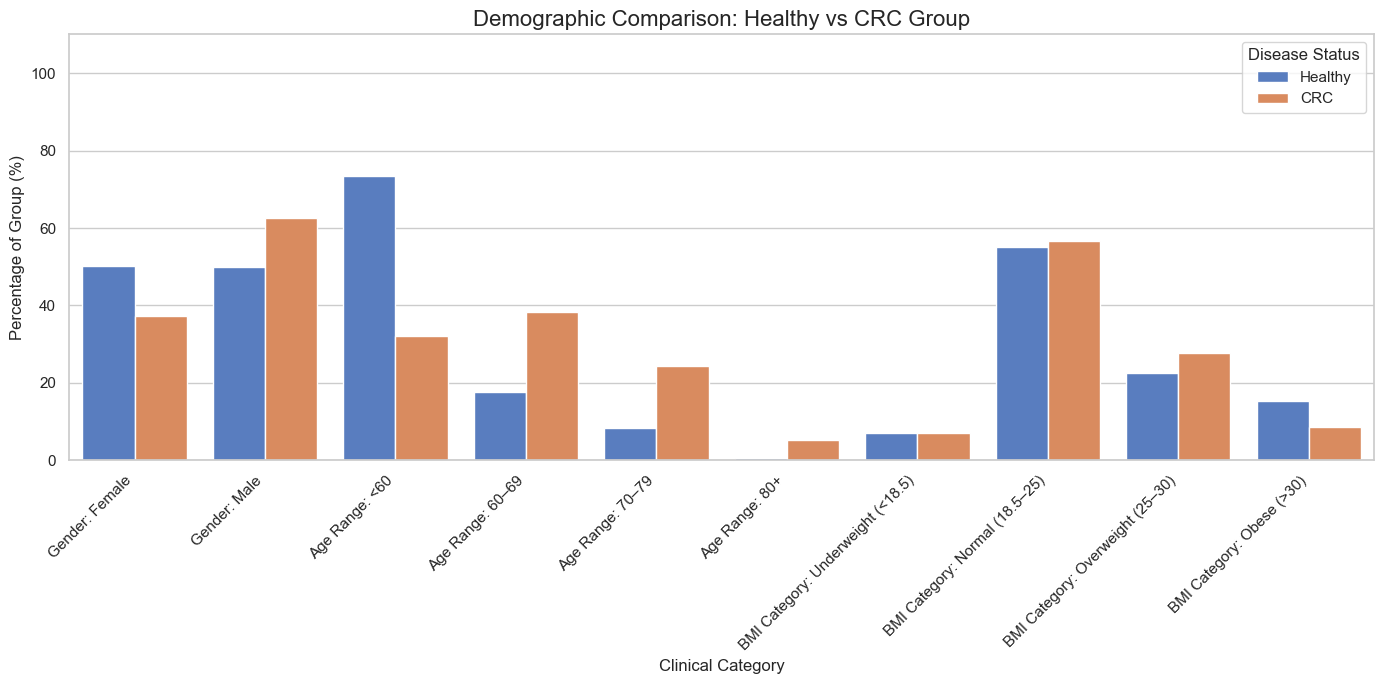

In [16]:
# Initialize the figure
plt.figure(figsize=(14, 7))

# Create the grouped bar chart
chart = sns.barplot(
    data=combined_df, 
    x='PlotLabel', 
    y='Percentage (%)', 
    hue='Group',
    palette='muted'
)

# Customizing the layout
plt.title('Demographic Comparison: Healthy vs CRC Group', fontsize=16)
plt.xlabel('Clinical Category', fontsize=12)
plt.ylabel('Percentage of Group (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap
plt.legend(title='Disease Status', loc='upper right')
plt.ylim(0, 110) # Ensure space for labels and 100% bars

plt.tight_layout()
plt.show()